# **Practical No-02: Text Classification using Embedding Layer and LSTM**

**Course Name: GENERATIVE AI**

**Student Name: RAGAV SHARMA**

**Student ID: 202401110012**

**Step 1 — Mount Google Drive**

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


Step 2 — Create a folder for this practical

In [ ]:
import os

folder_path = "/content/drive/MyDrive/Gen AI 02"

os.makedirs(folder_path, exist_ok=True)

print("Folder ready:", folder_path)

Folder ready: /content/drive/MyDrive/Gen AI 02


**Step 3 — Extract the ZIP file**

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/RAGAV SHARMA _ MITAOE_NETSAGE-AI.zip"
extract_path = "/content/drive/MyDrive/Gen AI 02"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


**Step 4 — Load the dataset**

In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Gen AI Practical 02/Reviews.csv.zip"
extract_path = "/content/drive/MyDrive/Gen AI Practical 02"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    print("Files inside ZIP:")
    for name in zip_ref.namelist():
        print(name)

    zip_ref.extractall(extract_path)

print("\nExtraction completed.")

Files inside ZIP:
Reviews.csv

Extraction completed.


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/Gen AI Practical 02/Reviews.csv"
)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (568454, 10)


**Step 5 — View the dataset**

In [ ]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

**Step 6 — Check the rating distribution**

In [ ]:
print(df["Score"].value_counts().sort_index())

Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


**Step 7 — Create Positive/Negative sentiment**

For our assignment, we'll use:

1 and 2 → Negative (0)
3 → Remove
4 and 5 → Positive (1)

In [ ]:
# Remove neutral reviews
df = df[df["Score"] != 3].copy()

# Create sentiment labels
df["Sentiment"] = df["Score"].apply(
    lambda x: 1 if x >= 4 else 0
)

print("Dataset after removing neutral reviews:")
print(df.shape)

print("\nSentiment distribution:")
print(df["Sentiment"].value_counts())

Dataset after removing neutral reviews:
(525814, 11)

Sentiment distribution:
Sentiment
1    443777
0     82037
Name: count, dtype: int64


**Step 8 — Create a balanced dataset**

The dataset has many more positive reviews than negative ones. To make the LSTM classification fair, we'll select 10,000 positive + 10,000 negative = 20,000 reviews.

In [ ]:
# Separate positive and negative reviews
positive = df[df["Sentiment"] == 1]
negative = df[df["Sentiment"] == 0]

# Take 10,000 from each class
positive_sample = positive.sample(n=10000, random_state=42)
negative_sample = negative.sample(n=10000, random_state=42)

# Combine them
df_balanced = pd.concat(
    [positive_sample, negative_sample],
    axis=0
)

# Shuffle the dataset
df_balanced = df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Balanced dataset shape:", df_balanced.shape)
print("\nClass distribution:")
print(df_balanced["Sentiment"].value_counts())

Balanced dataset shape: (20000, 11)

Class distribution:
Sentiment
0    10000
1    10000
Name: count, dtype: int64


**Step 9 — Keep only the columns we need**

For the LSTM, we don't need all 11 columns. We only need the review text and sentiment.

In [ ]:
df_balanced = df_balanced[["Text", "Sentiment"]]

df_balanced.head()

,Text,Sentiment
0,I ordered 3 boxes of 18 each.............and o...,0
1,I use red clover tea a lot and so do my friend...,1
2,I was concerned after buying this due to the n...,1
3,If you look forward to kicking back and the en...,1
4,"This should be sold as a medium roast coffee, ...",0


**Step 10 — Clean the Review Text**

In [ ]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)       # Remove HTML tags
    text = re.sub(r'[^a-zA-Z\s]', ' ', text) # Keep letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    return text

df_balanced["Clean_Text"] = df_balanced["Text"].apply(clean_text)

df_balanced[["Text", "Clean_Text", "Sentiment"]].head()

,Text,Clean_Text,Sentiment
0,I ordered 3 boxes of 18 each.............and o...,i ordered boxes of each and opened one box to ...,0
1,I use red clover tea a lot and so do my friend...,i use red clover tea a lot and so do my friend...,1
2,I was concerned after buying this due to the n...,i was concerned after buying this due to the n...,1
3,If you look forward to kicking back and the en...,if you look forward to kicking back and the en...,1
4,"This should be sold as a medium roast coffee, ...",this should be sold as a medium roast coffee a...,0


**Step 11 — Separate X and y**

In [ ]:
X = df_balanced["Clean_Text"]
y = df_balanced["Sentiment"]

print("Number of reviews:", len(X))
print("Number of labels:", len(y))

Number of reviews: 20000
Number of labels: 20000


**Step 12 — Split into Training and Testing Data**

80% → Training
20% → Testing

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


**Step 13 — Tokenization**

Now we convert words into numbers because an LSTM cannot directly process normal text.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_WORDS = 10000

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

print("Vocabulary size:", len(tokenizer.word_index))

Vocabulary size: 24484


**Step 14 — Convert Text to Sequences**


In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print("Example sequence:")
print(X_train_seq[0])

Example sequence:
[3, 16, 232, 1007, 7, 282, 9, 135, 3, 88, 950, 38, 294, 61, 8406, 23, 540, 6, 16, 1066, 25, 2, 71, 1704, 12, 5, 1777, 1790, 28, 3, 344, 6, 5, 1385, 42, 3224, 32, 6, 23, 5, 325, 431, 4, 3, 16, 866, 5, 944, 32, 314, 6, 23, 320, 380, 38, 17, 41, 18, 163, 232, 12, 5, 1435, 565, 48, 9, 53, 3564, 1024, 3, 89, 3388, 7, 689, 2220, 13, 20, 5, 1180, 1435, 32, 17, 712, 2, 1032, 4632, 670, 131, 11, 5, 325, 431, 73, 28, 9, 16, 5, 181, 79, 380, 12, 51, 3, 175, 722, 128, 64, 3, 20, 17, 3, 69, 21, 123, 3, 175, 30, 447, 6, 103, 3, 688, 6, 52, 49, 500, 19, 67, 325, 431, 3565, 43, 44, 680, 2404, 6, 114, 12, 5, 203, 365, 25, 6, 23, 305, 3, 124, 2, 117, 820, 892, 6, 26, 5, 1174, 126, 6, 309, 54, 910, 717, 301, 49, 573, 11, 5, 630, 2004, 3, 118, 60, 5, 1, 43, 2, 554, 2329, 82, 8406, 23, 540, 12, 9, 426, 2, 1328, 2221, 27, 172, 931, 5, 1116, 7, 3065, 905, 2481, 8, 3888, 4, 542, 2292, 35, 25, 2, 2617, 8, 1652, 515, 3, 60, 2, 2221, 27, 48, 492, 287, 35, 287, 3, 39, 200, 2, 3888, 4, 542, 214, 

**Step 15 — Padding**


Different reviews have different lengths. LSTM needs sequences of the same length, so we'll use padding.

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Testing shape:", X_test_pad.shape)

Training shape: (16000, 200)
Testing shape: (4000, 200)


**Step 16 — Build the Embedding + LSTM Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Model parameters
VOCAB_SIZE = 10000
EMBEDDING_DIM = 128
LSTM_UNITS = 64

# Build the model
model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    LSTM(LSTM_UNITS),

    Dropout(0.5),

    Dense(1, activation="sigmoid")
])

# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**1. Embedding Layer**

Converts word IDs into meaningful numerical vectors

In [ ]:
Embedding(
    input_dim=10000,
    output_dim=128
)

<Embedding name=embedding_1, built=False>

**2. LSTM Layer**

Learns patterns and relationships in the sequence of words.

In [ ]:
LSTM(64)

<LSTM name=lstm_1, built=False>

**3. Dense Layer**

Produces the final binary classification:

In [ ]:
activation="sigmoid"

**Step 17 — Compile the Model**

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


**Step 18 — Train the Model**

Now we'll train it using the 16,000 training reviews.

In [ ]:
EPOCHS = 5
BATCH_SIZE = 64

history = model.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 75s 348ms/step - accuracy: 0.5087 - loss: 0.6940 - val_accuracy: 0.5066 - val_loss: 0.6925
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 61s 305ms/step - accuracy: 0.5045 - loss: 0.6915 - val_accuracy: 0.5069 - val_loss: 0.6905
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 422ms/step - accuracy: 0.5214 - loss: 0.6811 - val_accuracy: 0.5141 - val_loss: 0.6914
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 83s 414ms/step - accuracy: 0.5291 - loss: 0.6728 - val_accuracy: 0.5128 - val_loss: 0.6980
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 59s 294ms/step - accuracy: 0.5226 - loss: 0.6722 - val_accuracy: 0.5031 - val_loss: 0.6941


**Step 19 — Evaluate on Test Data**

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.5033 - loss: 0.6967
Test Loss: 0.6967313289642334
Test Accuracy: 0.503250002861023


**Step 20 — Plot Training and Validation Accuracy**

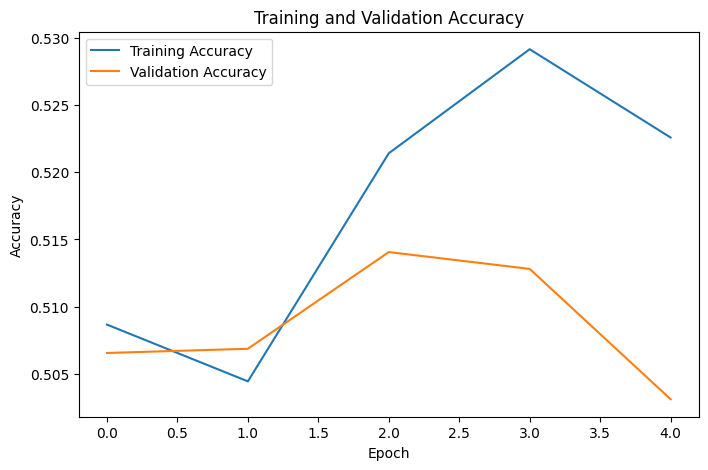

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

**Step 21 — Plot Training and Validation Loss**

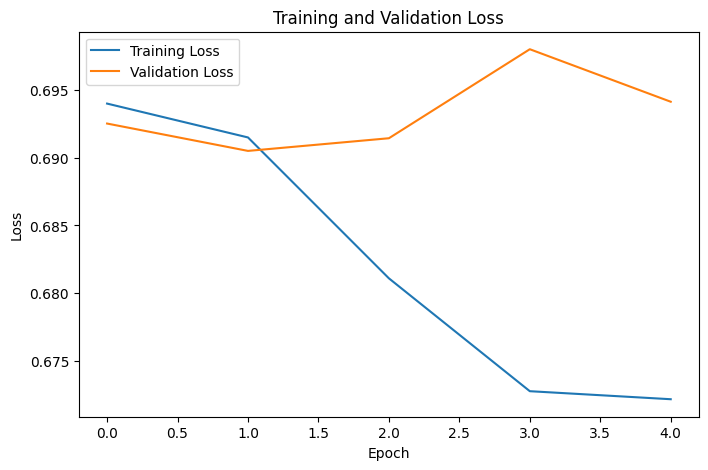

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

**Step 22 — Generate Predictions**

In [ ]:
import numpy as np

# Predict probabilities
y_pred_prob = model.predict(X_test_pad)

# Convert probabilities to 0 or 1
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step
Predictions generated successfully!
Number of predictions: 4000


**Step 23 — Classification Report**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Classification Metrics")
print("----------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")

Classification Metrics
----------------------
Accuracy  : 0.5032
Precision : 0.6275
Recall    : 0.0160
F1-Score  : 0.0312


**Step 24 — Detailed Classification Report**

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.50      0.99      0.67      2000
    Positive       0.63      0.02      0.03      2000

    accuracy                           0.50      4000
   macro avg       0.56      0.50      0.35      4000
weighted avg       0.56      0.50      0.35      4000



**Step 25 — Confusion Matrix**

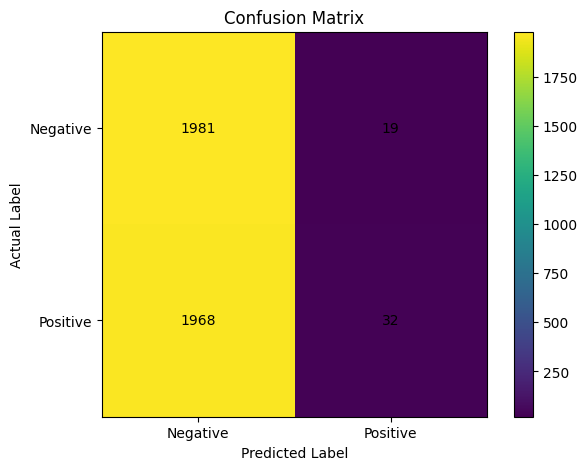

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Negative", "Positive"]
)

plt.yticks(
    [0, 1],
    ["Negative", "Positive"]
)

# Add numbers inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.show()

Step 26 — Display the Confusion Matrix Numerically

In [ ]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1981   19]
 [1968   32]]


**Step 76 — Test the Model With Your Own Reviews**

In [ ]:
def predict_sentiment(review):
    # Clean the review
    cleaned = clean_text(review)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences([cleaned])

    # Pad the sequence
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # Predict
    probability = model.predict(padded, verbose=0)[0][0]

    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, probability

In [ ]:
reviews = [
    "This product is excellent and I really enjoyed using it.",
    "The product was terrible and I am very disappointed.",
    "I love this product. It works perfectly.",
    "The quality is poor and I would not recommend it."
]

for review in reviews:
    sentiment, probability = predict_sentiment(review)

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Probability:", round(probability, 4))
    print("-" * 70)

Review: This product is excellent and I really enjoyed using it.
Prediction: Negative
Probability: 0.4992
----------------------------------------------------------------------
Review: The product was terrible and I am very disappointed.
Prediction: Negative
Probability: 0.4992
----------------------------------------------------------------------
Review: I love this product. It works perfectly.
Prediction: Negative
Probability: 0.4992
----------------------------------------------------------------------
Review: The quality is poor and I would not recommend it.
Prediction: Negative
Probability: 0.4992
----------------------------------------------------------------------
